In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import os

In [2]:
pt = 'results/*.csv'
csv_files = glob.glob(pt)
csv_files = sorted(csv_files)
print(f"Found {len(csv_files)} files:")
for file in csv_files:
    print(f"  - {os.path.basename(file)}")

Found 5 files:
  - no_prune_res.csv
  - prune_050_res.csv
  - prune_075_res.csv
  - prune_090_res.csv
  - prune_095_res.csv


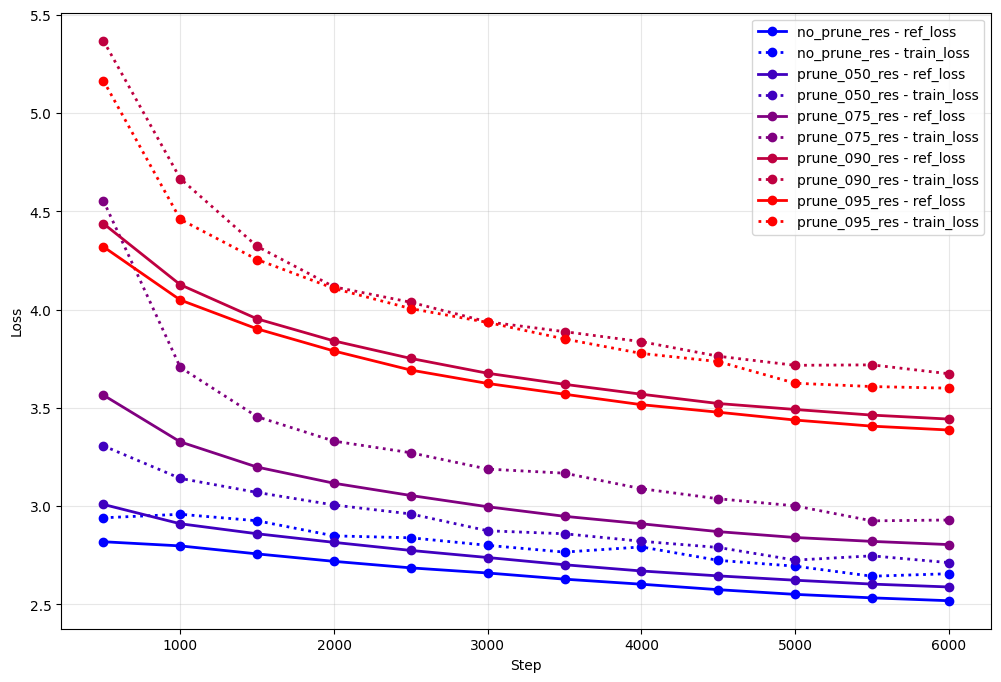

In [3]:
plt.figure(figsize=(12, 8))

total_files = len(csv_files)

for i, file in enumerate(csv_files):
    df = pd.read_csv(file)
    filename = os.path.splitext(os.path.basename(file))[0]
    if total_files <= 1:
        color = (0, 0, 1) 
    else:
        t = i / (total_files - 1)
        r = t                   
        g = 0                     
        b = 1 - t                
        color = (r, g, b)
    plt.plot(df['step'], df['ref_loss'], 
             label=f'{filename} - ref_loss', 
             linestyle='-',
             marker='o',
             color=color, 
             linewidth=2)
    
    plt.plot(df['step'], df['train_loss'], 
             label=f'{filename} - train_loss', 
             linestyle=':',
             marker='o',
             color=color,
             linewidth=2)

plt.grid(True, alpha=0.3)
plt.legend()
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()